In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

DATA = r'../data/processed/'

wk  = pd.read_csv(DATA + 'dengue_semanal_municipio_completo.csv')
gee = pd.read_csv(DATA + 'gee_lst_municipios.csv', low_memory=False)
end = pd.read_csv(DATA + 'municipios_endemicos.csv')

print(f'Semanas x municipio : {len(wk):,} filas | {wk["COD_MUN_O"].nunique()} municipios')
print(f'GEE diario          : {len(gee):,} filas | {gee["ADM2_CODE"].nunique()} municipios')
print(f'Municipios endémicos D4: {len(end):,}')

Semanas x municipio : 248,913 filas | 583 municipios
GEE diario          : 7,140,450 filas | 1086 municipios
Municipios endémicos D4: 621


## 1. Variable objetivo

=== Distribución de casos graves semanales por municipio ===
count    248913.000000
mean          0.196145
std           1.207009
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          82.000000
Name: grave, dtype: float64

Filas con grave = 0 : 224,082 (90.0%)
Filas con grave > 0 : 24,831 (10.0%)


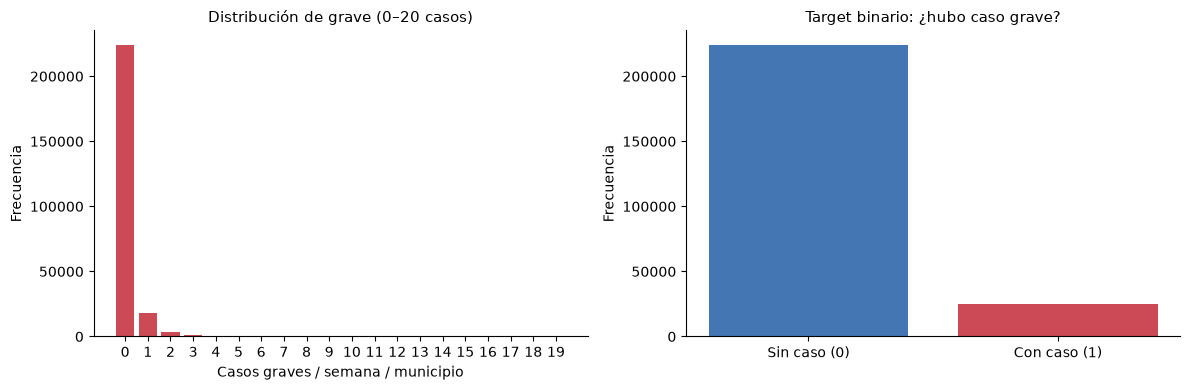

In [2]:
print('=== Distribución de casos graves semanales por municipio ===')
print(wk['grave'].describe())
print(f"\nFilas con grave = 0 : {(wk['grave']==0).sum():,} ({(wk['grave']==0).mean()*100:.1f}%)")
print(f"Filas con grave > 0 : {(wk['grave']>0).sum():,} ({(wk['grave']>0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = wk['grave'].value_counts().sort_index().head(20)
axes[0].bar(vc.index.astype(str), vc.values, color='#BE1D2B', alpha=0.8)
axes[0].set_title('Distribución de grave (0–20 casos)', fontsize=11)
axes[0].set_xlabel('Casos graves / semana / municipio')
axes[0].set_ylabel('Frecuencia')
axes[0].spines[['top','right']].set_visible(False)

wk['target_bin'] = (wk['grave'] > 0).astype(int)
vc2 = wk['target_bin'].value_counts().sort_index()
axes[1].bar(['Sin caso (0)', 'Con caso (1)'], vc2.values,
            color=['#1654A2','#BE1D2B'], alpha=0.8)
axes[1].set_title('Target binario: ¿hubo caso grave?', fontsize=11)
axes[1].set_ylabel('Frecuencia')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/figures/11b_target_distribucion.png', dpi=130, bbox_inches='tight')
plt.show()

## 2. Features de rezago epidemiológico (SIVIGILA)

Los rezagos de casos previos son el predictor más fuerte en epidemias de dengue.  
Ciclos epidémicos de 4–8 semanas → rezagos hasta t-8.

- **`grave_lag_X`** (X=1,2,3,4,8): casos graves semana t-X  
- **`clasico_lag_X`** (X=1,2,3,4,8): dengue clásico t-X (precede al grave ~1-2 sem.)  
- **`grave_roll4` / `clasico_roll4`**: suma acumulada últimas 4 semanas

In [3]:
wk = wk.sort_values(['COD_MUN_O','ANO','SEMANA']).reset_index(drop=True)

for lag in [1, 2, 3, 4, 8]:
    wk[f'grave_lag_{lag}']   = wk.groupby('COD_MUN_O')['grave'].shift(lag)
    wk[f'clasico_lag_{lag}'] = wk.groupby('COD_MUN_O')['clasico'].shift(lag)

wk['grave_roll4']   = wk.groupby('COD_MUN_O')['grave'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).sum())
wk['clasico_roll4'] = wk.groupby('COD_MUN_O')['clasico'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).sum())

lag_cols = [c for c in wk.columns if 'lag' in c or 'roll' in c]
print(f'Features de rezago: {len(lag_cols)}')

corr_lag = (wk[lag_cols + ['grave']].reset_index(drop=True)
              .corr()['grave'].drop('grave').sort_values(ascending=False))
print('\nCorrelación con grave:')
print(corr_lag.to_string())

Features de rezago: 12

Correlación con grave:
grave_roll4      0.382345
grave_lag_3      0.281832
grave_lag_1      0.265977
grave_lag_2      0.260447
grave_lag_8      0.240188
grave_lag_4      0.218118
clasico_roll4    0.190751
clasico_lag_2    0.142327
clasico_lag_1    0.127947
clasico_lag_3    0.126773
clasico_lag_4    0.119368
clasico_lag_8    0.092886


## 3. Features de temperatura (GEE / MODIS LST)

La temperatura superficial terrestre (LST) modula la reproducción de *Aedes aegypti*.  
Ciclo de desarrollo del vector ~10–14 días → temperatura t-2 a t-4 semanas es la más relevante.

**Nota técnica:** `COD_MUN_O` en SIVIGILA es el código de 3 dígitos dentro del departamento,  
mientras que `ADM2_CODE` en GEE es el código DANE de 5 dígitos (ej. 76001 = Cali).  
Se construye la unión por nombre de municipio normalizado.

In [4]:
# Agregar GEE a nivel semanal
gee['fecha'] = pd.to_datetime(gee['fecha'])
gee['ANO']    = gee['fecha'].dt.isocalendar().year.astype(int)
gee['SEMANA'] = gee['fecha'].dt.isocalendar().week.astype(int)
gee['mun_key'] = gee['ADM2_NAME'].str.upper().str.strip()

lst_sem = (
    gee.groupby(['mun_key','ANO','SEMANA'])['lst_celsius']
    .mean().reset_index()
    .rename(columns={'lst_celsius':'lst_media'})
)
print(f'GEE semanal: {len(lst_sem):,} filas | {lst_sem["mun_key"].nunique()} municipios')

# Clave de unión en SIVIGILA: nombre normalizado
wk['mun_key'] = wk['Municipio_ocurrencia'].str.upper().str.strip()

# Cobertura del join por nombre
sivigila_munis = set(wk['mun_key'].unique())
gee_munis      = set(lst_sem['mun_key'].unique())
match = sivigila_munis & gee_munis
print(f'Municipios SIVIGILA: {len(sivigila_munis)} | GEE: {len(gee_munis)} | Match: {len(match)}')

wk = wk.merge(lst_sem, on=['mun_key','ANO','SEMANA'], how='left').reset_index(drop=True)
print(f'Filas después del join: {len(wk):,}')
print(f'lst_media cobertura: {wk["lst_media"].notna().mean()*100:.1f}%')

wk = wk.sort_values(['mun_key','ANO','SEMANA']).reset_index(drop=True)
for lag in [1, 2, 4]:
    wk[f'lst_lag_{lag}'] = wk.groupby('mun_key')['lst_media'].shift(lag)

lst_cols = ['lst_media','lst_lag_1','lst_lag_2','lst_lag_4']
for c in lst_cols:
    print(f'  {c}: {wk[c].notna().mean()*100:.1f}% con dato')

GEE semanal: 946,580 filas | 1007 municipios
Municipios SIVIGILA: 1094 | GEE: 1007 | Match: 864


Filas después del join: 248,913
lst_media cobertura: 83.5%
  lst_media: 83.5% con dato
  lst_lag_1: 83.2% con dato
  lst_lag_2: 82.9% con dato
  lst_lag_4: 82.3% con dato


## 4. Features temporales y estacionalidad

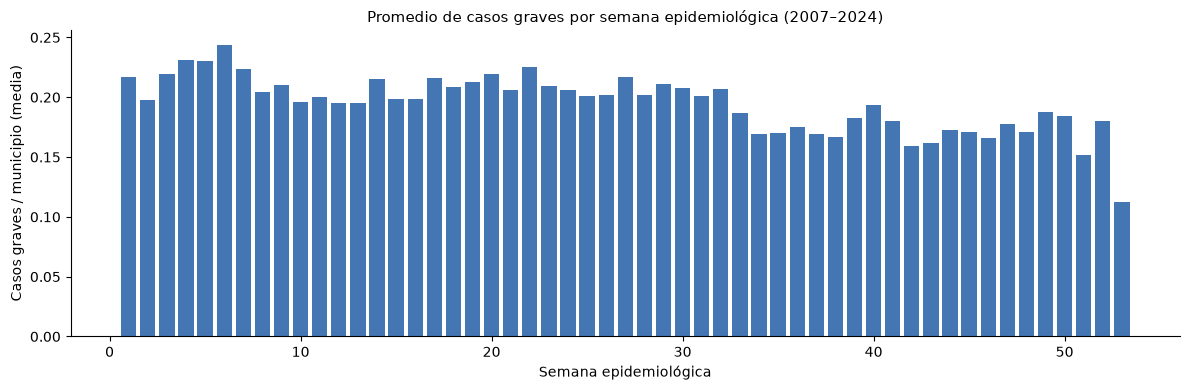

In [5]:
# Codificación cíclica: evita discontinuidad semana 52→1
wk['semana_sin'] = np.sin(2 * np.pi * wk['SEMANA'] / 52)
wk['semana_cos'] = np.cos(2 * np.pi * wk['SEMANA'] / 52)
wk['anio_epidemia'] = wk['ANO'].isin({2010,2016,2019,2023}).astype(int)

season = wk.groupby('SEMANA')['grave'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(season.index, season.values, color='#1654A2', alpha=0.8, width=0.8)
ax.set_title('Promedio de casos graves por semana epidemiológica (2007–2024)', fontsize=11)
ax.set_xlabel('Semana epidemiológica')
ax.set_ylabel('Casos graves / municipio (media)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../data/figures/12_estacionalidad_grave.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Features de canal endémico y endemicidad

El canal endémico (Bortman, 1999) clasifica la semana t-1 de cada municipio como:  
- **0 – Normal**: `grave_lag_1` < P25 histórico  
- **1 – Alerta**: P25 ≤ `grave_lag_1` < P75  
- **2 – Exceso**: `grave_lag_1` ≥ P75  

Referencia: 2007–2022.

In [6]:
wk['es_endemico'] = wk['COD_MUN_O'].isin(end['COD_MUN_O']).astype(int)

ref = wk[wk['ANO'].between(2007, 2022)]
canal_ref = (
    ref.groupby(['COD_MUN_O','SEMANA'])['grave']
    .agg(p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    .reset_index()
)

wk = wk.merge(canal_ref, on=['COD_MUN_O','SEMANA'], how='left').reset_index(drop=True)

def zona_canal(row):
    if pd.isna(row['p25']) or pd.isna(row['grave_lag_1']): return np.nan
    if row['grave_lag_1'] < row['p25']: return 0
    if row['grave_lag_1'] < row['p75']: return 1
    return 2

wk['zona_canal_lag1'] = wk.apply(zona_canal, axis=1)

vc = wk['zona_canal_lag1'].value_counts(dropna=False)
vc.index = [str(i) for i in vc.index]
print('Zona canal (grave_lag_1):', dict(vc))

Zona canal (grave_lag_1): {'2.0': np.int64(216772), '1.0': np.int64(29672), 'nan': np.int64(1634), '0.0': np.int64(835)}


In [7]:
# SIR: Standardized Incidence Ratio
# SIR_lag1 = grave_lag_1 / media_historica(grave) para ese municipio y semana (ref 2007-2022)
# SIR > 1 => casos la semana pasada superaron la media historica; SIR = 0 => sin casos
sir_ref = (
    wk[wk['ANO'].between(2007, 2022)]
    .groupby(['COD_MUN_O', 'SEMANA'])['grave']
    .mean()
    .reset_index()
    .rename(columns={'grave': 'expected_grave'})
)
wk = wk.merge(sir_ref, on=['COD_MUN_O', 'SEMANA'], how='left').reset_index(drop=True)

# Cuando expected = 0 el ratio es indefinido (nunca hubo casos historicos esa semana)
wk['sir_lag1'] = wk['grave_lag_1'] / wk['expected_grave'].replace(0, float('nan'))

print(f'SIR lag1 cobertura: {wk["sir_lag1"].notna().mean()*100:.1f}%')
print(wk['sir_lag1'].describe().round(3))


SIR lag1 cobertura: 61.4%
count    152866.000
mean          0.919
std           3.559
min           0.000
25%           0.000
50%           0.000
75%           0.000
max         224.000
Name: sir_lag1, dtype: float64


## 6. Resumen de features y correlaciones

In [8]:
FEATURE_COLS = (
    [f'grave_lag_{l}'   for l in [1,2,3,4,8]] +
    [f'clasico_lag_{l}' for l in [1,2,3,4,8]] +
    ['grave_roll4','clasico_roll4'] +
    ['lst_media','lst_lag_1','lst_lag_2','lst_lag_4'] +
    ['semana_sin','semana_cos','anio_epidemia','ANO','SEMANA'] +
    ['es_endemico','zona_canal_lag1','p25','p75','sir_lag1']
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in wk.columns]
TARGET = 'grave'
GRUPOS = (
    ['rezago_grave']*5 + ['rezago_clasico']*5 + ['rolling']*2 +
    ['temperatura']*4  + ['temporal']*5 + ['endemic_canal']*4
)

rows = []
for c, g in zip(FEATURE_COLS, GRUPOS):
    sub = wk[[c, TARGET]].dropna().reset_index(drop=True)
    corr_val = round(sub.corr().iloc[0,1], 3) if len(sub) > 1 else np.nan
    rows.append({'feature': c, 'grupo': g,
                 'cobertura_%': round(wk[c].notna().mean()*100, 1),
                 'corr_grave': corr_val})

summary = pd.DataFrame(rows)
print(f'Total features: {len(FEATURE_COLS)}')
print(summary.to_string(index=False))

Total features: 26
        feature          grupo  cobertura_%  corr_grave
    grave_lag_1   rezago_grave         99.8       0.266
    grave_lag_2   rezago_grave         99.5       0.260
    grave_lag_3   rezago_grave         99.3       0.282
    grave_lag_4   rezago_grave         99.1       0.218
    grave_lag_8   rezago_grave         98.2       0.240
  clasico_lag_1 rezago_clasico         99.8       0.128
  clasico_lag_2 rezago_clasico         99.5       0.142
  clasico_lag_3 rezago_clasico         99.3       0.127
  clasico_lag_4 rezago_clasico         99.1       0.119
  clasico_lag_8 rezago_clasico         98.2       0.093
    grave_roll4        rolling         99.8       0.382
  clasico_roll4        rolling         99.8       0.191
      lst_media    temperatura         83.5       0.015
      lst_lag_1    temperatura         83.2       0.014
      lst_lag_2    temperatura         82.9       0.013
      lst_lag_4    temperatura         82.3       0.013
     semana_sin       tempora

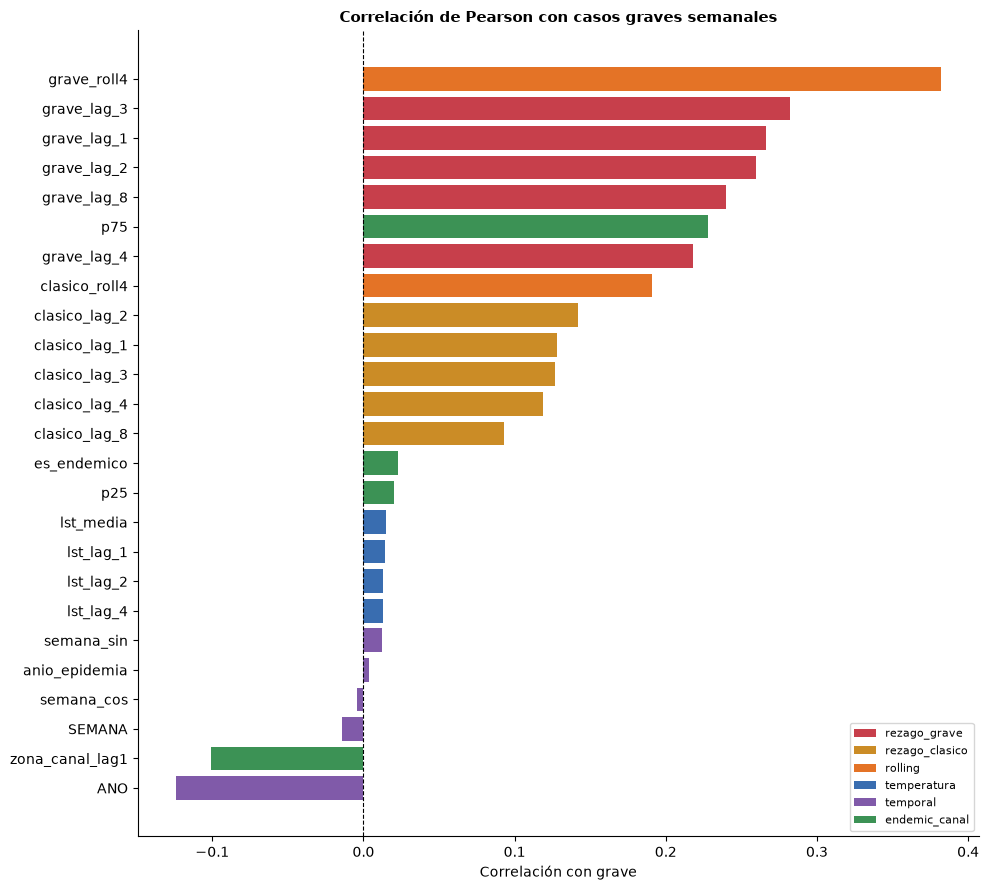

In [9]:
COLORS = {
    'rezago_grave':   '#BE1D2B',
    'rezago_clasico': '#C27800',
    'rolling':        '#E05A00',
    'temperatura':    '#1654A2',
    'temporal':       '#6A3D9A',
    'endemic_canal':  '#1A7F37',
}

ss = summary.dropna(subset=['corr_grave']).sort_values('corr_grave')
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(ss['feature'], ss['corr_grave'],
        color=[COLORS[g] for g in ss['grupo']], alpha=0.85)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Correlación de Pearson con casos graves semanales',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Correlación con grave')
ax.spines[['top','right']].set_visible(False)
ax.legend(handles=[Patch(facecolor=v, label=k, alpha=0.85) for k,v in COLORS.items()],
          fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('../data/figures/13_correlacion_features.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Variables descartadas (SIVIGILA individual)

| Grupo | Columnas | Razón |
|---|---|---|
| IDs administrativos | `CONSECUTIVE, COD_PRE, COD_SUB` | Sin valor predictivo |
| Variables de resultado | `PAC_HOS, CON_FIN, FEC_HOS, FEC_DEF` | Contemporáneas al caso, no leading |
| Tipo confirmación | `TIP_CAS, nom_est_f_caso` | Administrativo |
| Demografía | `SEXO, EDAD, AREA, TIP_SS` | Sin relación de adelanto temporal |
| >99% nulos | `FM_FUERZA, FM_UNIDAD, FM_GRADO` | Datos militares |
| >80% nulos | `estrato, fuente, nom_grupo, sem_ges` | - |
| >83% nulos | `CBMTE, COD_PAIS_R, Pais_residencia` | - |
| Cobertura/grupo | `COD_ASE, GRU_POB, GP_* (12 cols)` | Sin relación epidemiológica directa |


## 8. Dataset final de modelado

In [10]:
keep = list(dict.fromkeys(
    ['COD_MUN_O','mun_key','Departamento_ocurrencia','ANO','SEMANA',TARGET] + FEATURE_COLS
))
keep = [c for c in keep if c in wk.columns]

df_model = (
    wk[keep]
    .dropna(subset=['grave_lag_1','grave_lag_2'])
    .reset_index(drop=True)
)

print(f'Dataset de modelado : {len(df_model):,} filas x {len(df_model.columns)} cols')
print(f'Período             : {df_model["ANO"].min()} – {df_model["ANO"].max()}')
print(f'Municipios          : {df_model["COD_MUN_O"].nunique()}')

nulls = df_model[FEATURE_COLS].isnull().mean() * 100
print('\nNulos por feature:')
for col, pct in nulls[nulls > 0].sort_values(ascending=False).items():
    print(f'  {col}: {pct:.1f}%')
print('  (XGBoost maneja nulos nativamente)')

df_model.to_csv(DATA + 'dengue_features_modelado.csv', index=False)
print(f'\nGuardado: {DATA}dengue_features_modelado.csv')

Dataset de modelado : 247,766 filas x 30 cols
Período             : 2007 – 2024
Municipios          : 554

Nulos por feature:
  sir_lag1: 38.4%
  lst_lag_4: 17.4%
  lst_lag_2: 16.7%
  lst_lag_1: 16.6%
  lst_media: 16.4%
  clasico_lag_8: 1.3%
  grave_lag_8: 1.3%
  clasico_lag_4: 0.4%
  grave_lag_4: 0.4%
  zona_canal_lag1: 0.4%
  p25: 0.4%
  p75: 0.4%
  clasico_lag_3: 0.2%
  grave_lag_3: 0.2%
  (XGBoost maneja nulos nativamente)



Guardado: ../data/processed/dengue_features_modelado.csv


## 9. Desbalance de clases: estrategias

| Estrategia | Descripción | Cuándo usar |
|---|---|---|
| `scale_pos_weight` | Pondera positivos × n_neg/n_pos ≈ 9 | Siempre como baseline |
| SMOTE | Genera ejemplos sintéticos de la clase positiva | Si F1 es muy bajo en positivos |
| Umbral ajustado | Bajar threshold 0.5 → ~0.2 | Maximizar sensibilidad (alerta) |
| Target: exceso | Predecir `zona_canal_lag1 == 2` en t+1 | Más alineado con el objetivo operativo |

**Métricas:** F1, PR-AUC, Sensibilidad. No usar ROC-AUC (optimista con clases desbalanceadas).

## 10. Partición temporal (sin data leakage)

| Split | Años | Propósito |
|---|---|---|
| Entrenamiento | 2007–2021 | Ajuste |
| Validación | 2022 | Hiperparámetros |
| Prueba | 2023–2024 | Evaluación final (epidemia 2023 incluida) |

In [ ]:
for name, split in [
    ('Train  2007–2021', df_model[df_model['ANO'] <= 2021]),
    ('Val    2022',      df_model[df_model['ANO'] == 2022]),
    ('Test   2023–2024', df_model[df_model['ANO'] >= 2023]),
]:
    n_pos = (split[TARGET] > 0).sum()
    print(f'{name}: {len(split):>7,} filas | {n_pos:,} positivos ({n_pos/len(split)*100:.1f}%)')
